In [9]:
from EncoderDecoder.utils import loadData
from EncoderDecoder.utils import latex_species
import matplotlib.pyplot as plt
import logging
import pandas as pd
from PCAfold import KernelDensity
import numpy as np
logging.disable(logging.CRITICAL)

In [2]:
import os

#add the root directory
os.chdir('../')

## Computed kernel density weighted PCA

In [3]:
path = "data-files/"
name_state_space = "Malik-state-space-CFLF-2022.csv"

data_state_space = pd.read_csv(path + name_state_space)

In [5]:
species_conditioning = "CO2"

kerneld = KernelDensity(data_state_space.to_numpy(), data_state_space["CO2"].to_numpy())

In [6]:
print(type(kerneld))

<class 'PCAfold.preprocess.KernelDensity'>


In [ ]:
weights = kerneld.weights

# check weights sum to 1

2757.382183683225


In [13]:
print(type(weights))
print(weights.shape)
print(np.max(weights))

<class 'numpy.ndarray'>
(89849, 1)
1.0


### Save the kernel density weights

In [14]:
np.save("data-files/extraData/kernelDensity/2026-08-06-kernelDensity-Malik-CFLF-2022-condition-CO2", weights)

### Perform kernel denisty weighted PCA

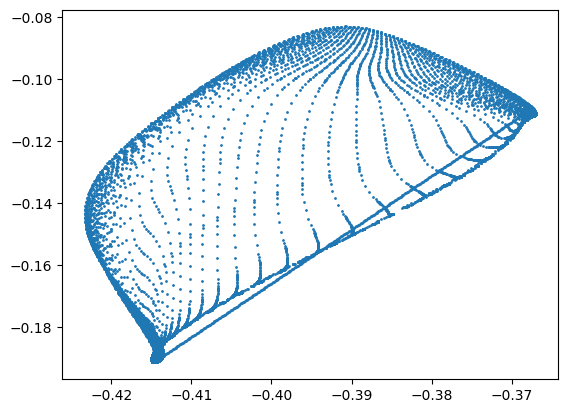

In [27]:
species = ["CH4", "CO", "O2", "CO2", "H2O", "N2"]
scaling = "pareto"

data_state_space_major = data_state_space[species]
X = data_state_space_major.to_numpy()

mean = np.mean(X, axis = 0)
std = np.std(X, axis = 0)

X_scaled = (X - mean)/np.sqrt(std)

X_hat = weights*X_scaled

U, S, Vt = np.linalg.svd(X_hat, full_matrices=False)

components = Vt

PC1 = X @ Vt[:, 0]
PC2 = X @ Vt[:, 1]

plt.scatter(PC1, PC2, s=1)
plt.show()

In [ ]:
species = ["CH4", "CO", "O2", "CO2", "H2O", "N2"]
scaling = "pareto"

data_state_space_major = data_state_space[species]
X = data_state_space_major.to_numpy()

mean = np.mean(X, axis = 0)
std = np.std(X, axis = 0)

X_scaled = (X - mean)/np.sqrt(std)

X_hat = weights*X_scaled

U, S, Vt = np.linalg.svd(X_hat, full_matrices=False)

components = Vt

PC1 = X @ Vt[:, 0]
PC2 = X @ Vt[:, 1]

plt.scatter(PC1, PC2, s=1)
plt.show()